## Compare Distributions

In [2]:
# imports and configurations
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import os

work_dir = "/jumbo/keller-lab/Jeremy_Wang/eplus_sa/scripts/main" # Change this to your working directory

In [3]:
# Load the data
for seed in range(1, 6):
    seed_name = f"seed_{seed}"
    normal_indices = pd.read_csv(
        f"{work_dir}/sobol_indices/{seed_name}/totalorder_indices.csv"
    )
    uniform_indices = pd.read_csv(
        f"{work_dir}/sobol_indices_uniform/{seed_name}/totalorder_indices.csv"
    )
    beta_indices = pd.read_csv(
        f"{work_dir}/sobol_indices_beta/{seed_name}/totalorder_indices.csv"
    )
    realdata_indices = pd.read_csv(
        f"{work_dir}/sobol_indices_realdata/{seed_name}/totalorder_indices.csv"
    )
    # append
    if seed == 1:
        all_normal_indices = normal_indices
        all_uniform_indices = uniform_indices
        all_beta_indices = beta_indices
        all_realdata_indices = realdata_indices
    else:
        all_normal_indices = pd.concat([all_normal_indices, normal_indices], ignore_index=True)
        all_uniform_indices = pd.concat([all_uniform_indices, uniform_indices], ignore_index=True)
        all_beta_indices = pd.concat([all_beta_indices, beta_indices], ignore_index=True)
        all_realdata_indices = pd.concat([all_realdata_indices, realdata_indices], ignore_index=True)

In [4]:
all_dfs = []

# Load all distributions + seeds
for seed in range(1, 6):

    seed_name = f"seed_{seed}"

    # -----------------------------
    # Normal
    # -----------------------------
    normal_df = pd.read_csv(
        f"{work_dir}/sobol_indices/{seed_name}/totalorder_indices.csv"
    )

    normal_df["distribution"] = "Normal"
    normal_df["seed"] = seed

    all_dfs.append(normal_df)

    # -----------------------------
    # Uniform
    # -----------------------------
    uniform_df = pd.read_csv(
        f"{work_dir}/sobol_indices_uniform/{seed_name}/totalorder_indices.csv"
    )

    uniform_df["distribution"] = "Uniform"
    uniform_df["seed"] = seed

    all_dfs.append(uniform_df)

    # -----------------------------
    # Beta
    # -----------------------------
    beta_df = pd.read_csv(
        f"{work_dir}/sobol_indices_beta/{seed_name}/totalorder_indices.csv"
    )

    beta_df["distribution"] = "Beta"
    beta_df["seed"] = seed

    all_dfs.append(beta_df)
    # -----------------------------
    # Real Data
    # -----------------------------
    realdata_df = pd.read_csv(
        f"{work_dir}/sobol_indices_realdata/{seed_name}/totalorder_indices.csv"
    )

    realdata_df["distribution"] = "Real Data"
    realdata_df["seed"] = seed

    all_dfs.append(realdata_df)

# Combine everything
all_indices = pd.concat(all_dfs, ignore_index=True)

In [5]:
average_df = (
    all_indices.groupby("distribution", as_index=False)
      .mean(numeric_only=True)
)
average_df = average_df.drop(columns="seed")

In [6]:
average_df

,distribution,heating_setpoint,people_per_area,infil_flow_rate_living,infil_flow_rate_garage,infil_flow_rate_attic,watts_equip,watts_lights,heating_COP,fan_efficiency,pressure_rise,solar_transmittance,burner_eff,vent_flow_rate,cooling_setpoint_gap
0,Beta,0.606404,0.000128,0.000401,4.112017e-06,0.000034,0.005618,0.030232,0.142058,0.005181,0.005201,0.000913,0.0,0.114329,0.096102
1,Normal,0.586659,0.000103,0.000360,3.501880e-06,0.000027,0.005517,0.029685,0.141832,0.005305,0.005267,0.000845,0.0,0.111687,0.118458
2,Real Data,0.388923,0.000016,0.362178,1.251299e-07,0.000004,0.000988,0.191876,0.055052,0.002337,0.002312,0.000109,0.0,0.008275,0.000210
3,Uniform,0.606992,0.000092,0.000328,3.269737e-06,0.000027,0.005619,0.030393,0.143858,0.005220,0.005220,0.000867,0.0,0.114031,0.095218


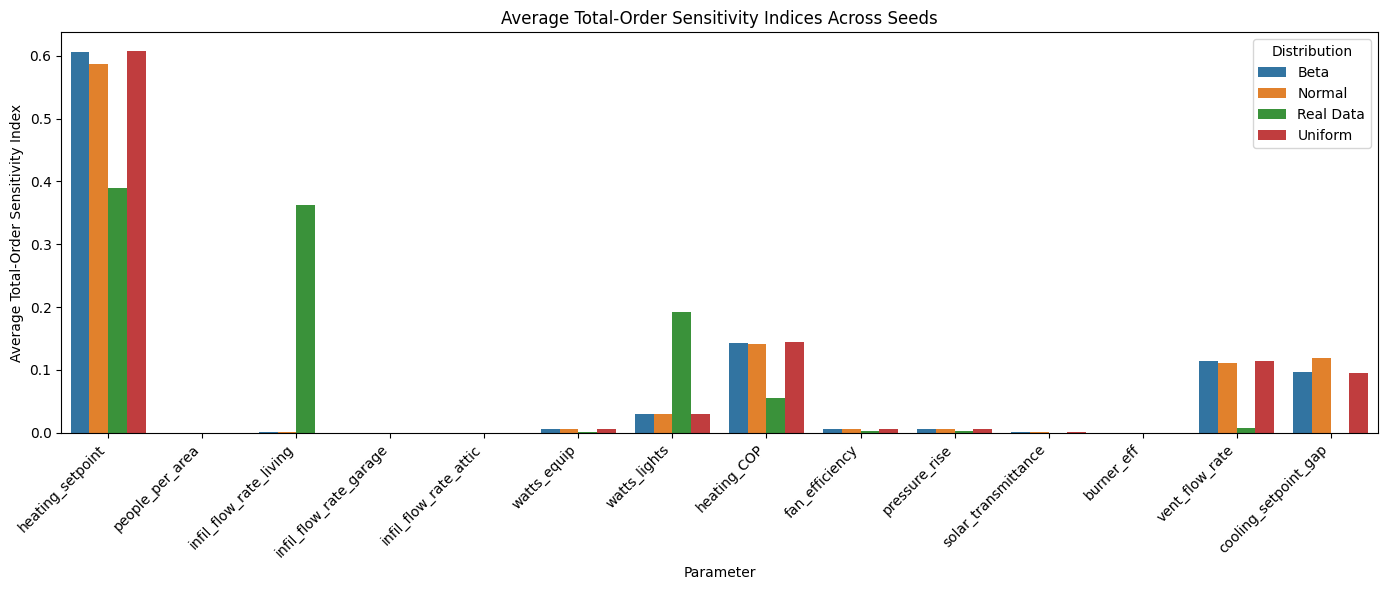

In [7]:
# Convert from wide to long format
plot_df = average_df.melt(
    id_vars="distribution",
    var_name="parameter",
    value_name="ST"
)

plt.figure(figsize=(14, 6))

sns.barplot(
    data=plot_df,
    x="parameter",
    y="ST",
    hue="distribution",
    errorbar=None
)

plt.xlabel("Parameter")
plt.ylabel("Average Total-Order Sensitivity Index")
plt.title("Average Total-Order Sensitivity Indices Across Seeds")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Distribution")
figure_dir = os.path.join(work_dir, "figures_realdata")
plt.savefig(
    os.path.join(figure_dir, "Comparisons.png"),
    dpi=300,
    bbox_inches="tight"
)
plt.tight_layout()
plt.show()



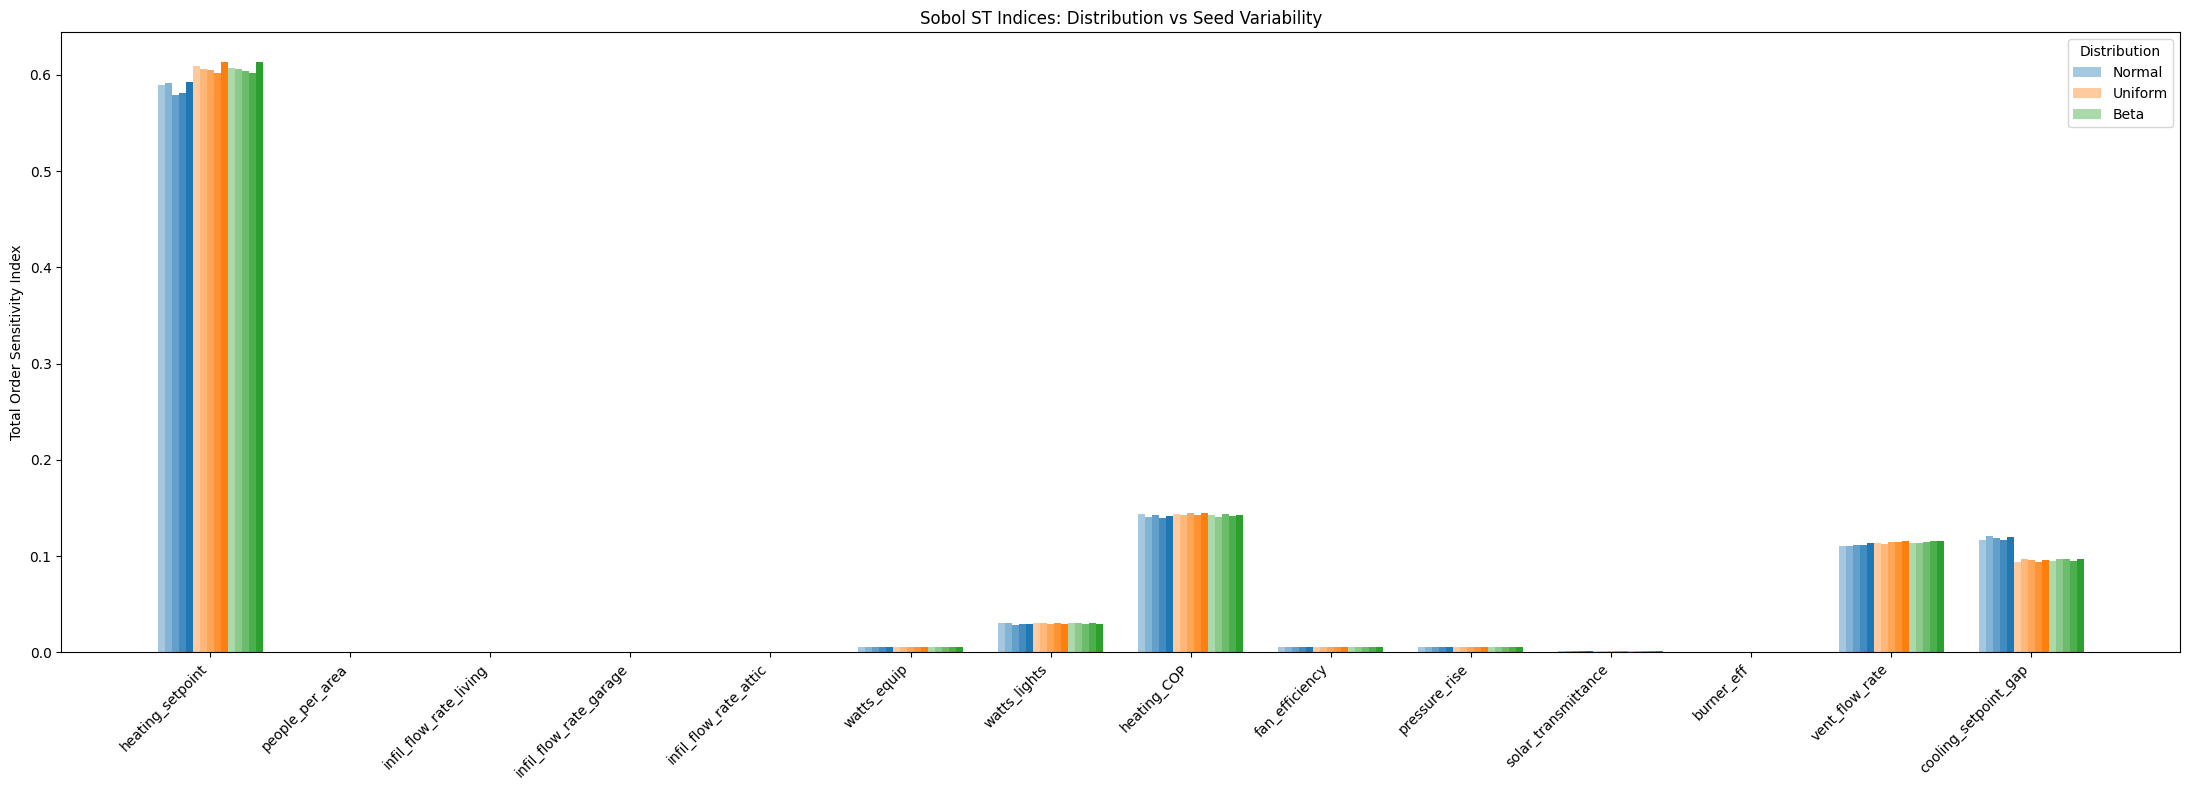

In [10]:
import numpy as np
import matplotlib.pyplot as plt

# Ensure long format
plot_df = pd.melt(
    all_indices,
    id_vars=["distribution", "seed"],
    var_name="parameter",
    value_name="ST"
)

# Setup
params = plot_df["parameter"].unique()
distributions = ["Normal", "Uniform", "Beta"]
seeds = sorted(plot_df["seed"].unique())

colors = {
    "Normal": "tab:blue",
    "Uniform": "tab:orange",
    "Beta": "tab:green"
}

fig, ax = plt.subplots(figsize=(22, 8))

x = np.arange(len(params))

bar_width = 0.25
seed_offsets = np.linspace(-0.1, 0.1, len(seeds))
alphas = np.linspace(0.4, 1.0, len(seeds))  # low seed → transparent

# Loop over distributions
for i, dist in enumerate(distributions):

    for j, seed in enumerate(seeds):

        subset = plot_df[
            (plot_df["distribution"] == dist) &
            (plot_df["seed"] == seed)
        ]

        # Align values in correct parameter order
        values = [
            subset.loc[subset["parameter"] == p, "ST"].values[0]
            for p in params
        ]

        ax.bar(
            x + i * bar_width + seed_offsets[j],
            values,
            width=bar_width / len(seeds),
            color=colors[dist],
            alpha=alphas[j],
            label=dist if j == 0 else None
        )

# Formatting
ax.set_xticks(x + bar_width)
ax.set_xticklabels(params, rotation=45, ha="right")

ax.set_ylabel("Total Order Sensitivity Index")
ax.set_title("Sobol ST Indices: Distribution vs Seed Variability")

ax.legend(title="Distribution")
plt.tight_layout()
plt.show()

### Compare Annual Consumption Graphs

In [19]:
annual_consumption_normal = pd.read_pickle(os.path.join(work_dir, "analysis_sobol", "annual_consumption.pkl"))
annual_consumption_uniform = pd.read_pickle(os.path.join(work_dir, "analysis_uniform", "annual_consumption.pkl"))
annual_consumption_beta = pd.read_pickle(os.path.join(work_dir, "analysis_beta", "annual_consumption.pkl"))
annual_consumption_realdata = pd.read_pickle(os.path.join(work_dir, "analysis_realdata", "annual_consumption.pkl"))

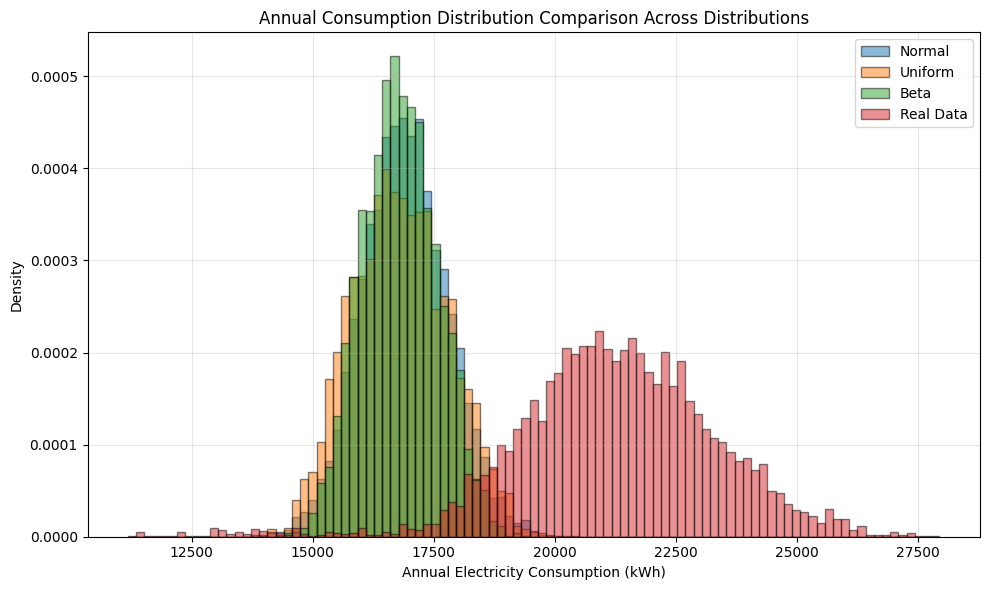

In [51]:
normal_kwh = annual_consumption_normal.loc[
    annual_consumption_normal["seed"] == "seed_1",
    "Electricity:Facility [kWh](Annual)"
]
uniform_kwh = annual_consumption_uniform.loc[
    annual_consumption_uniform["seed"] == "seed_1",
    "Electricity:Facility [kWh](Annual)"
]
beta_kwh = annual_consumption_beta.loc[
    annual_consumption_beta["seed"] == "seed_1",
    "Electricity:Facility [kWh](Annual)"
]
realdata_kwh = annual_consumption_realdata.loc[
    annual_consumption_realdata["seed"] == "seed_1",
    "Electricity:Facility [kWh](Annual)"
]

# Put all datasets together to determine common bin edges
all_values = np.concatenate([
    normal_kwh.to_numpy(),
    uniform_kwh.to_numpy(),
    beta_kwh.to_numpy(),
    realdata_kwh.to_numpy()
])

bins = np.linspace(all_values.min(), all_values.max(), 100)

plt.figure(figsize=(10, 6))

plt.hist(
    normal_kwh,
    bins=bins,
    density=True,
    alpha=0.5,
    edgecolor="black",
    label="Normal"
)

plt.hist(
    uniform_kwh,
    bins=bins,
    density=True,
    alpha=0.5,
    edgecolor="black",
    label="Uniform"
)

plt.hist(
    beta_kwh,
    bins=bins,
    density=True,
    alpha=0.5,
    edgecolor="black",
    label="Beta"
)

plt.hist(
    realdata_kwh,
    bins=bins,
    density=True,
    alpha=0.5,
    edgecolor="black",
    label="Real Data"
)

plt.xlabel("Annual Electricity Consumption (kWh)")
plt.ylabel("Density")
plt.title("Annual Consumption Distribution Comparison Across Distributions")
plt.legend()
plt.grid(alpha=0.3)
figure_dir = os.path.join(work_dir, "figures_realdata")
plt.savefig(
    os.path.join(figure_dir, "Annual_Consumption_Comparison.png"),
    dpi=300,
    bbox_inches="tight"
)

plt.tight_layout()

plt.show()

### Compare Prior Distributions

In [8]:
normal_prior = pd.read_csv(os.path.join(work_dir, "params_sobol", "simulation_parameters_seed_1.csv"))
uniform_prior = pd.read_csv(os.path.join(work_dir, "params_uniform", "simulation_parameters_seed_1.csv"))
beta_prior = pd.read_csv(os.path.join(work_dir, "params_beta", "simulation_parameters_seed_1.csv"))
realdata_prior = pd.read_csv(os.path.join(work_dir, "params_realdata", "simulation_parameters_seed_1.csv"))

In [37]:
normal_prior

,IDF_file,seed,heating_setpoint,cooling_setpoint,people_per_area,infil_flow_rate_living,infil_flow_rate_garage,infil_flow_rate_attic,watts_equip,watts_lights,heating_COP,fan_efficiency,pressure_rise,solar_transmittance,burner_eff,vent_flow_rate
0,randomized_1.idf,43,21.493279,26.847131,2.755789,0.010539,0.055542,0.051198,499.934332,1056.108678,4.063030,0.653022,395.234332,0.813567,0.876782,0.141178
1,randomized_2.idf,43,21.686903,27.040756,2.755789,0.010539,0.055542,0.051198,499.934332,1056.108678,4.063030,0.653022,395.234332,0.813567,0.876782,0.141178
2,randomized_3.idf,43,21.493279,26.847131,2.815625,0.010539,0.055542,0.051198,499.934332,1056.108678,4.063030,0.653022,395.234332,0.813567,0.876782,0.141178
3,randomized_4.idf,43,21.493279,26.847131,2.755789,0.009501,0.055542,0.051198,499.934332,1056.108678,4.063030,0.653022,395.234332,0.813567,0.876782,0.141178
4,randomized_5.idf,43,21.493279,26.847131,2.755789,0.010539,0.051872,0.051198,499.934332,1056.108678,4.063030,0.653022,395.234332,0.813567,0.876782,0.141178
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29995,randomized_29996.idf,43,23.049805,28.398434,3.093147,0.009755,0.046841,0.054652,537.554687,952.557487,3.928397,0.618896,389.964548,0.814860,0.796190,0.137147
29996,randomized_29997.idf,43,23.049805,28.398434,3.093147,0.009755,0.046841,0.054652,537.554687,952.557487,3.928397,0.618896,389.964548,0.794179,0.802393,0.137147
29997,randomized_29998.idf,43,23.049805,28.398434,3.093147,0.009755,0.046841,0.054652,537.554687,952.557487,3.928397,0.618896,389.964548,0.794179,0.796190,0.134712
29998,randomized_29999.idf,43,23.049805,29.773190,3.093147,0.009755,0.046841,0.054652,537.554687,952.557487,3.928397,0.618896,389.964548,0.794179,0.796190,0.137147


In [47]:
def plot_prior_distributions_overlay(distribution):
    plt.figure(figsize=(12, 6))
    
    plt.hist(
        normal_prior[distribution],
        bins = 100,
        density=True,
        alpha=0.5,
        edgecolor="black",
        label="Normal"
    )

    plt.hist(
        uniform_prior[distribution],
        bins = 100,
        density=True,
        alpha=0.5,
        edgecolor="black",
        label="Uniform"
    )

    plt.hist(
        beta_prior[distribution],
        bins = 100,
        density=True,
        alpha=0.5,
        edgecolor="black",
        label="Beta"
    )

    plt.hist(
        realdata_prior[distribution],
        bins = 100,
        density=True,
        alpha=0.5,
        edgecolor="black",
        label="Real Data"
    )

    
    plt.title(f"Prior Distributions for {distribution}")
    plt.xlabel("Parameter Value")
    plt.ylabel("Density")
    plt.legend()

    figure_dir = os.path.join(work_dir, "param_distributions")
    os.makedirs(figure_dir, exist_ok=True)

    plt.savefig(
        os.path.join(figure_dir, f"{distribution}.png"),
        dpi=300,
        bbox_inches="tight"
    )
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

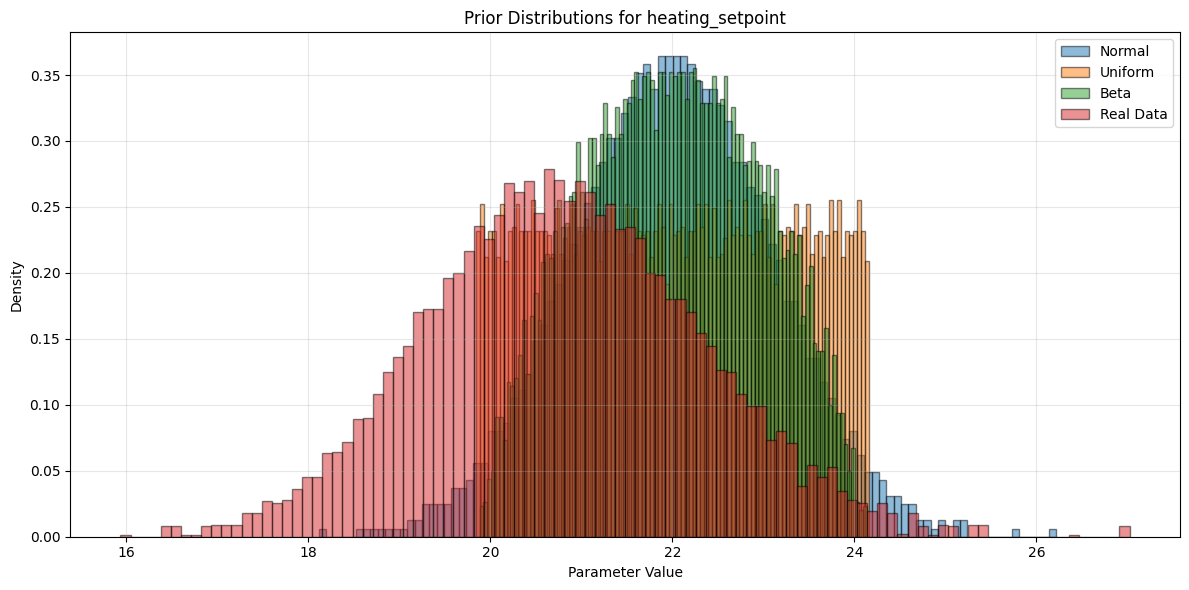

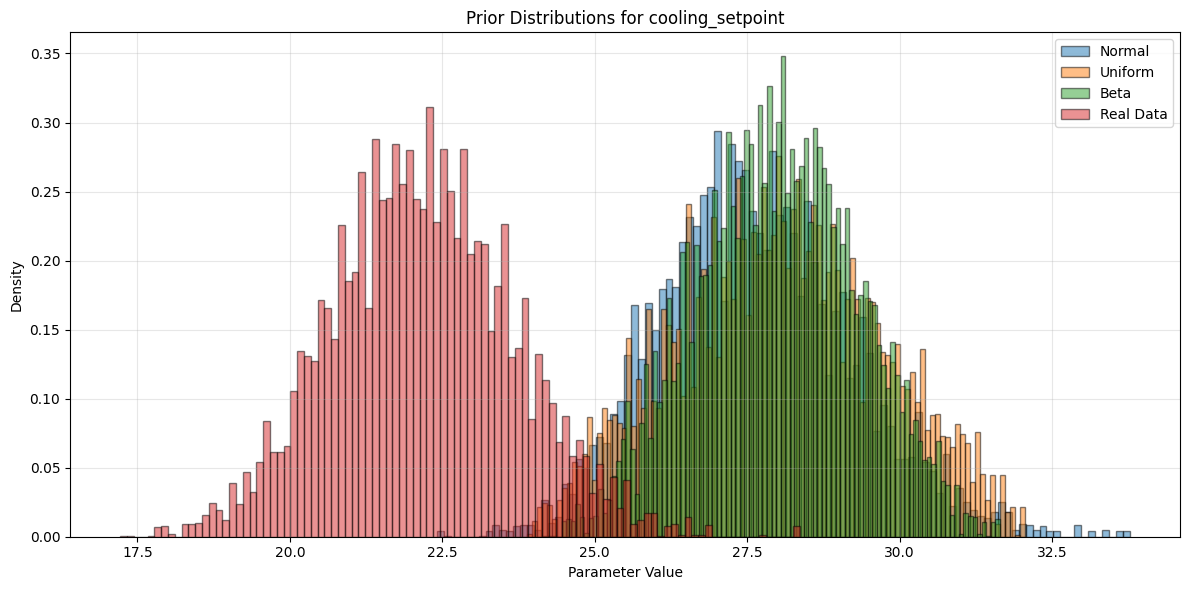

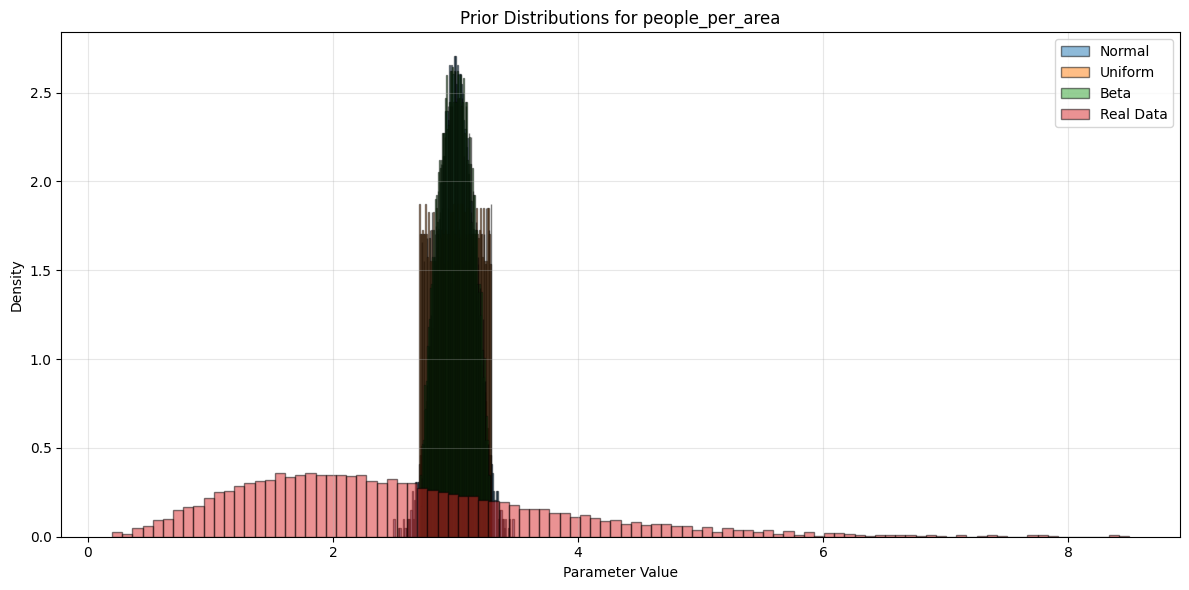

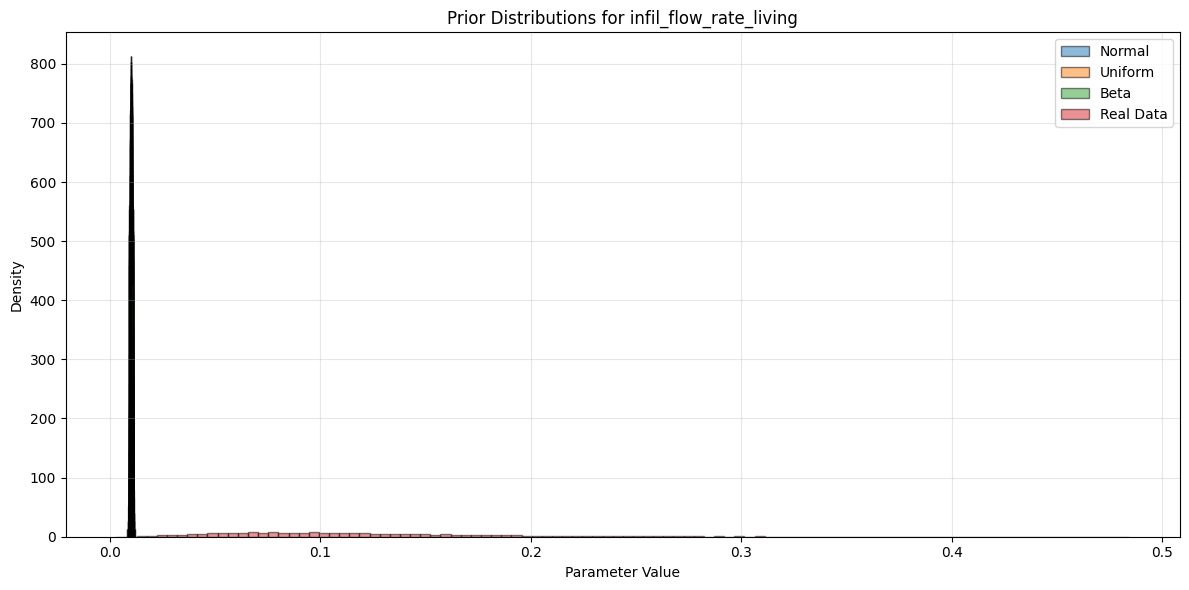

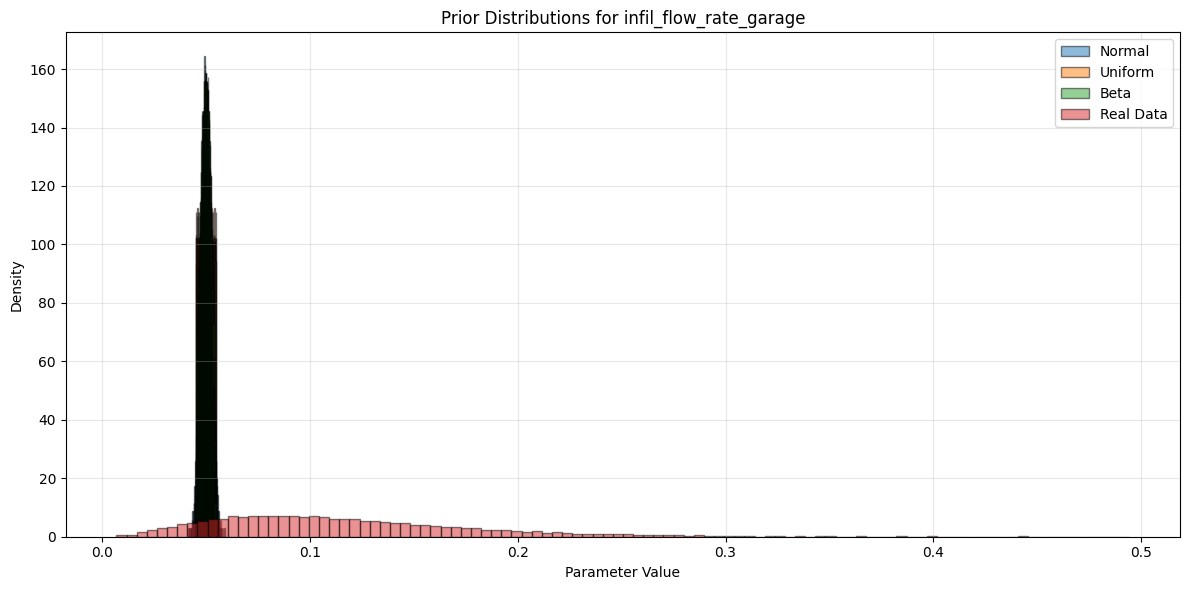

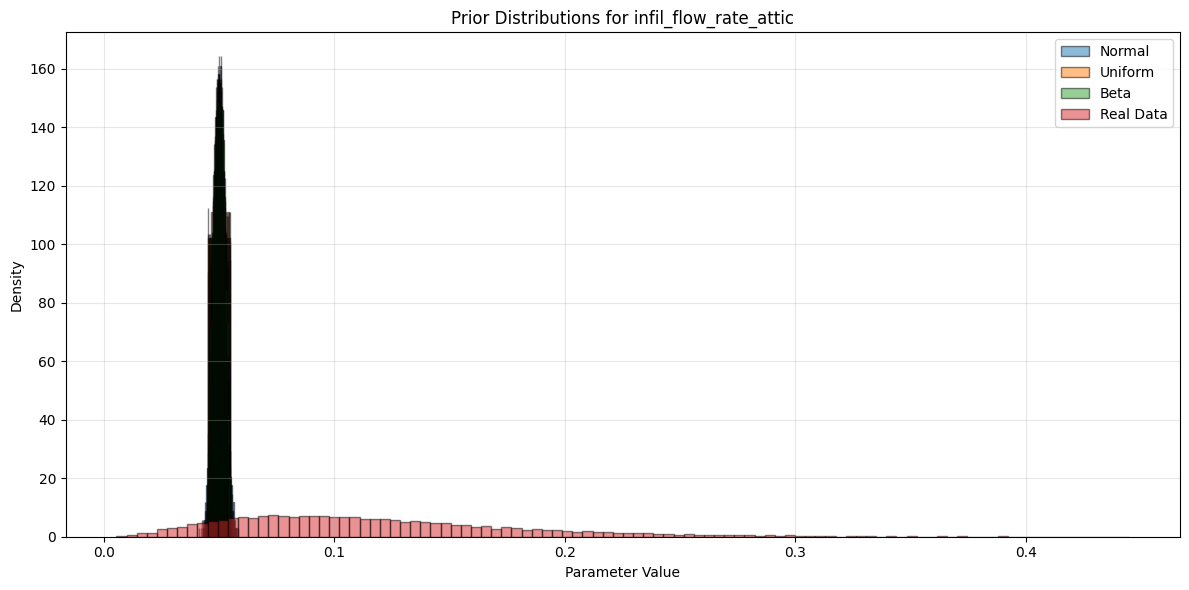

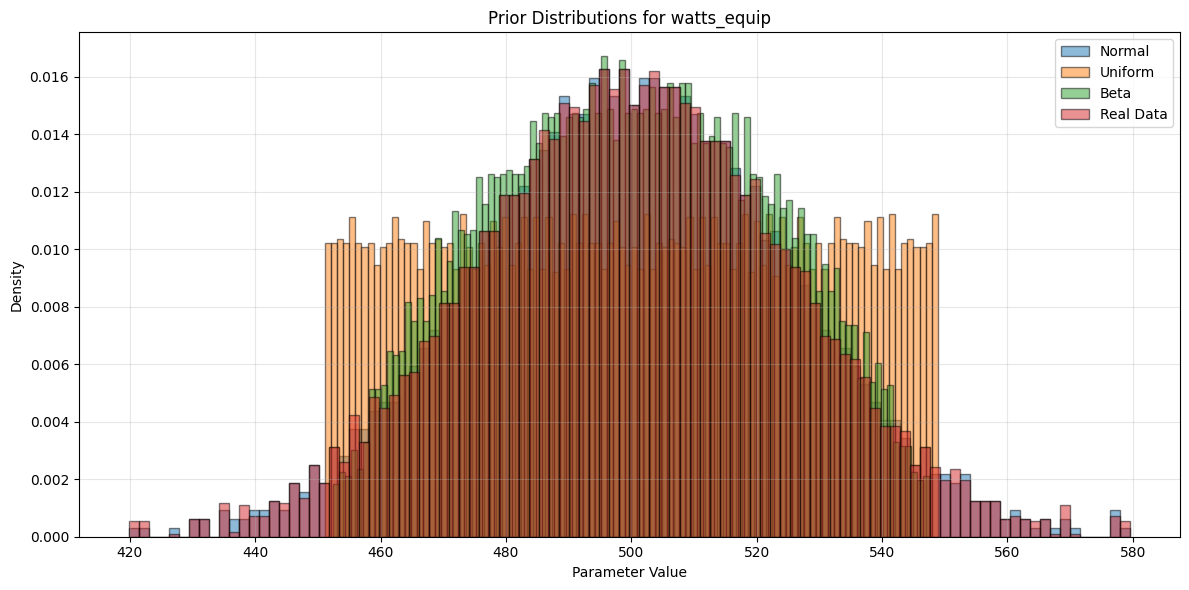

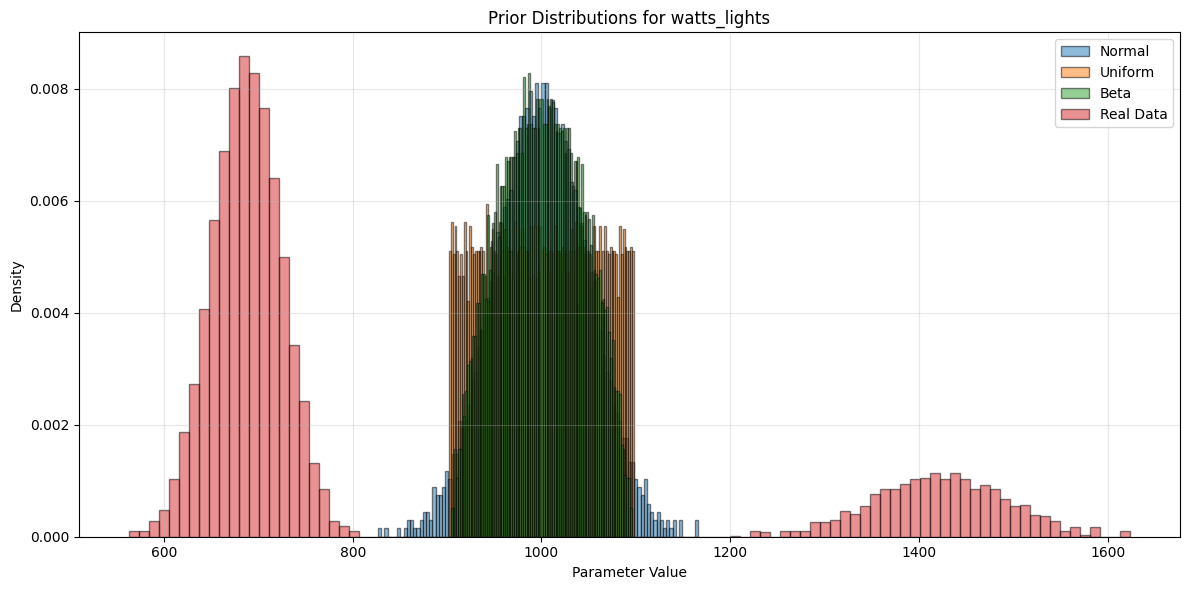

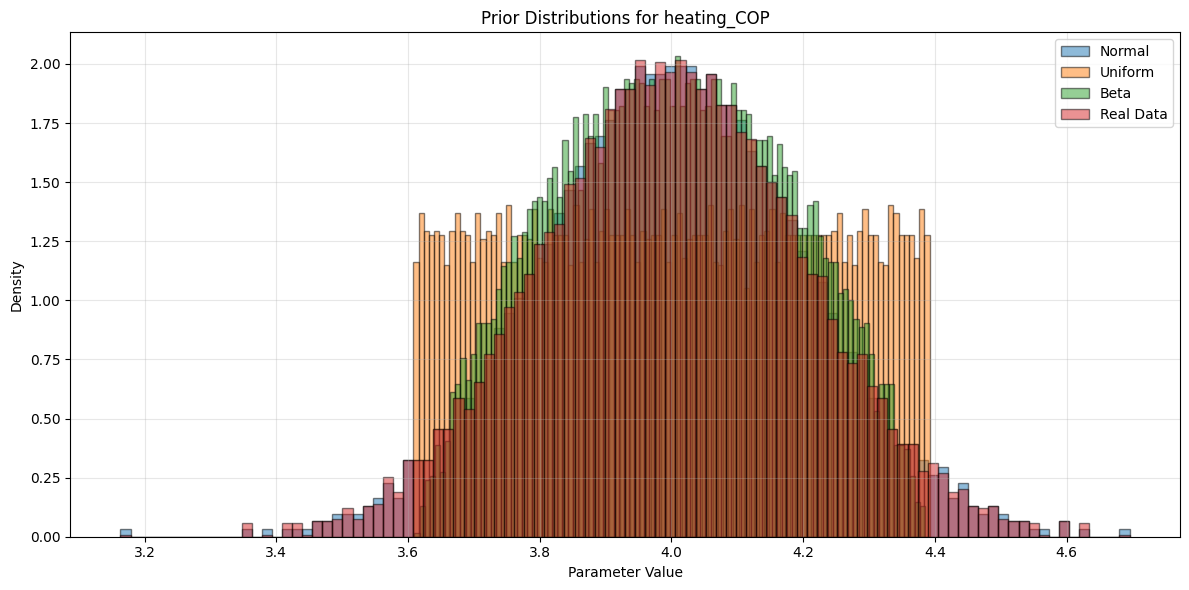

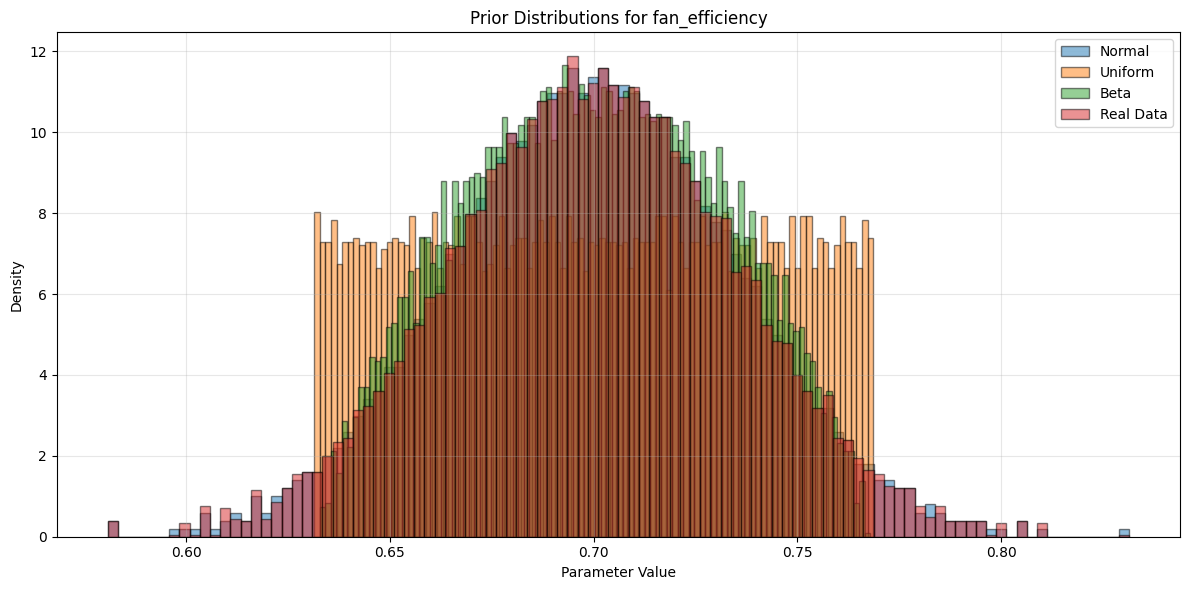

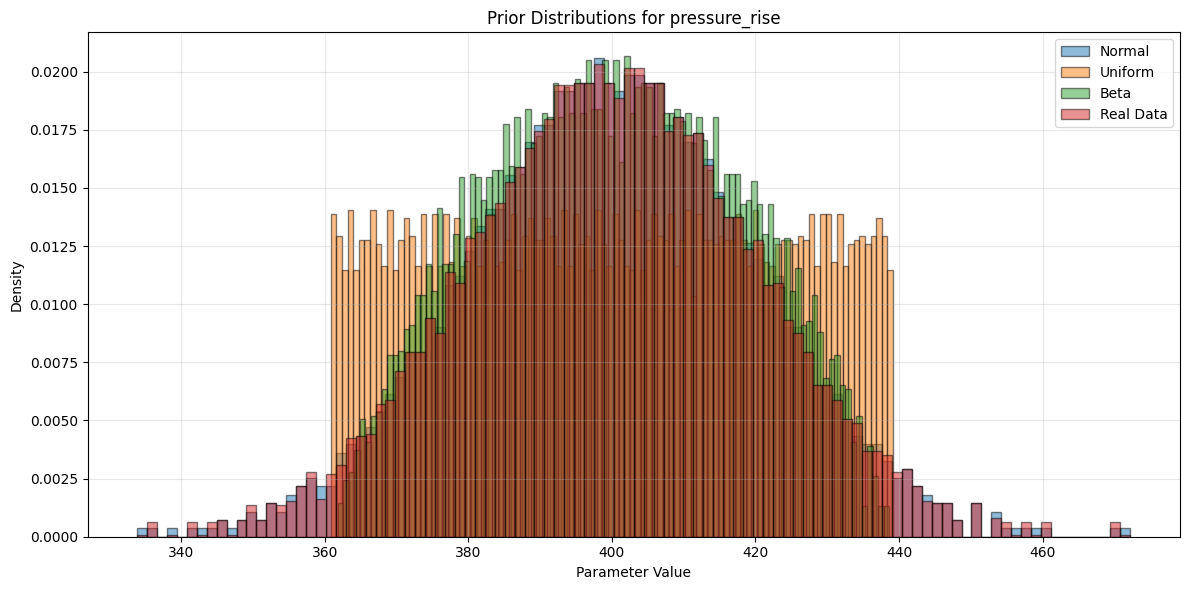

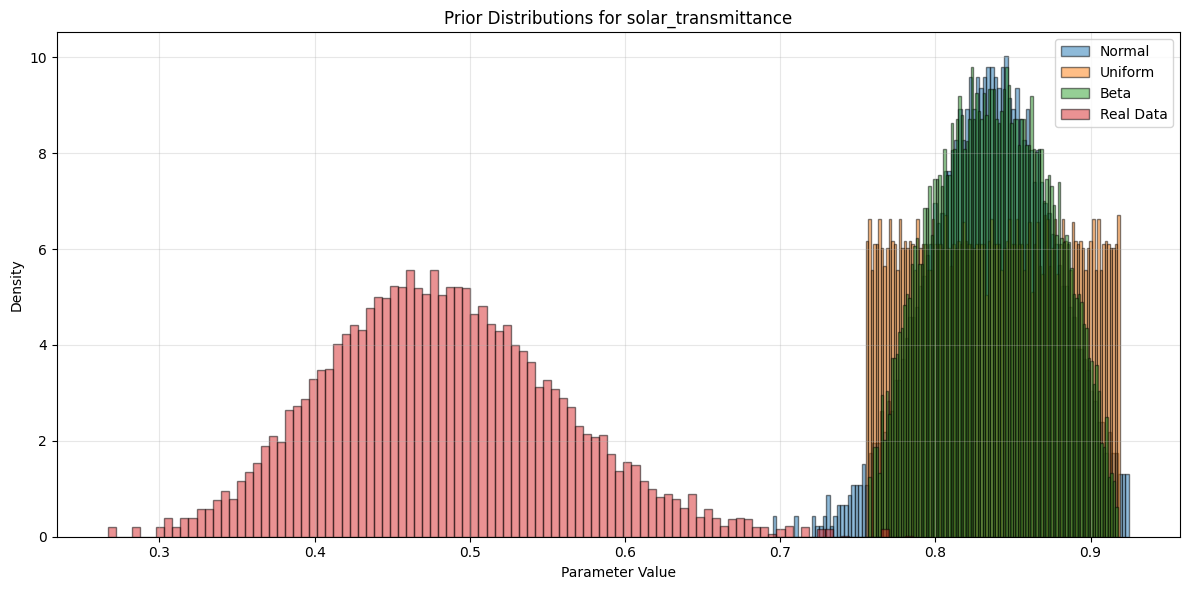

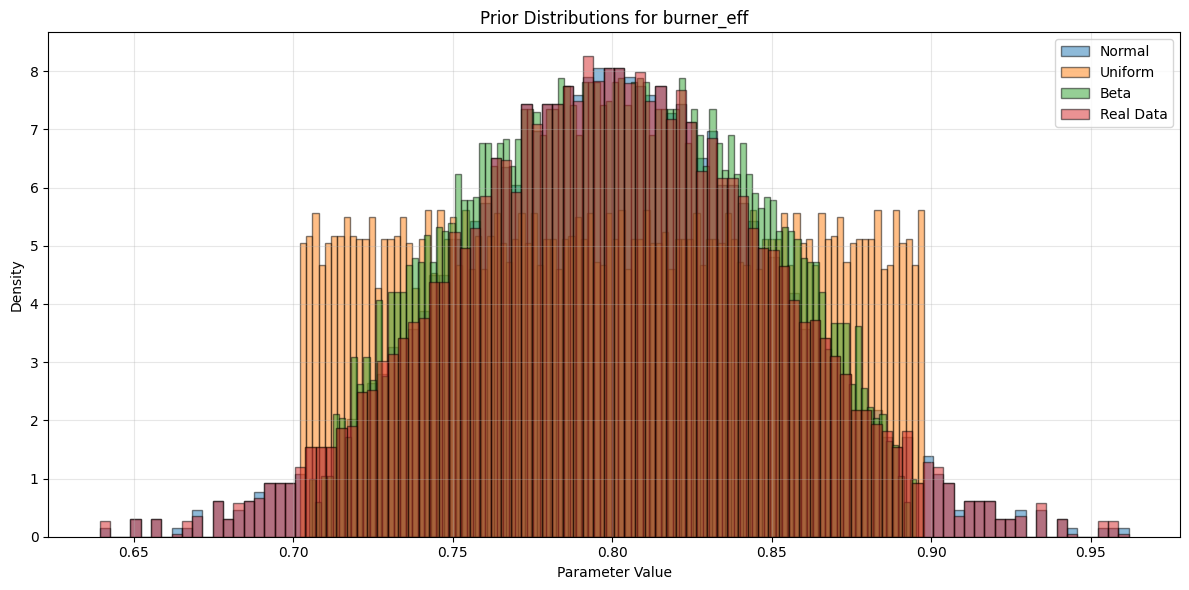

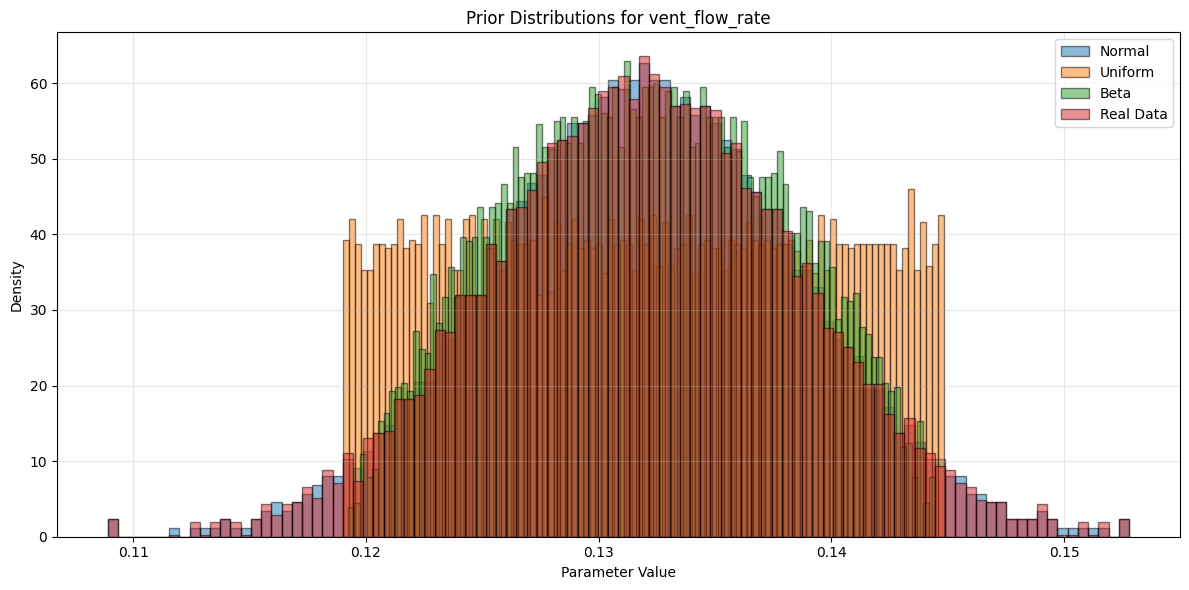

In [48]:
for param in normal_prior.columns:
    if param =='IDF_file' or param == 'seed':
        continue
    plot_prior_distributions_overlay(param)

### Overlaying Distributions on top of Real Data

In [1]:
import importlib
import resstock_library
importlib.reload(resstock_library)
from resstock_library import *

In [ ]:
def plot_real_overlay(distribution, realprior):
    plt.figure(figsize=(12, 6))
    
    plt.hist(
        normal_prior[distribution],
        bins = 100,
        density=True,
        alpha=0.5,
        edgecolor="black",
        label="Normal"
    )

    plt.hist(
        uniform_prior[distribution],
        bins = 100,
        density=True,
        alpha=0.5,
        edgecolor="black",
        label="Uniform"
    )

    plt.hist(
        beta_prior[distribution],
        bins = 100,
        density=True,
        alpha=0.5,
        edgecolor="black",
        label="Beta"
    )

    plt.hist(
        realdata_prior[distribution],
        bins = 100,
        density=True,
        alpha=0.5,
        edgecolor="black",
        label="Real Data Fit"
    )

    plt.bar(
        realprior.iloc[:, 0],   # values (e.g. Temp)
        realprior.iloc[:, 1],   # probabilities
        width=0.01,
        alpha=0.8,
        color="black",
        label="Real Data"
    )


    plt.title(f"Prior Distributions for {distribution}")
    plt.xlabel("Parameter Value")
    plt.ylabel("Density")
    plt.legend()

    figure_dir = os.path.join(work_dir, "param_distributions")
    os.makedirs(figure_dir, exist_ok=True)

    plt.savefig(
        os.path.join(figure_dir, f"{distribution}.png"),
        dpi=300,
        bbox_inches="tight"
    )
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

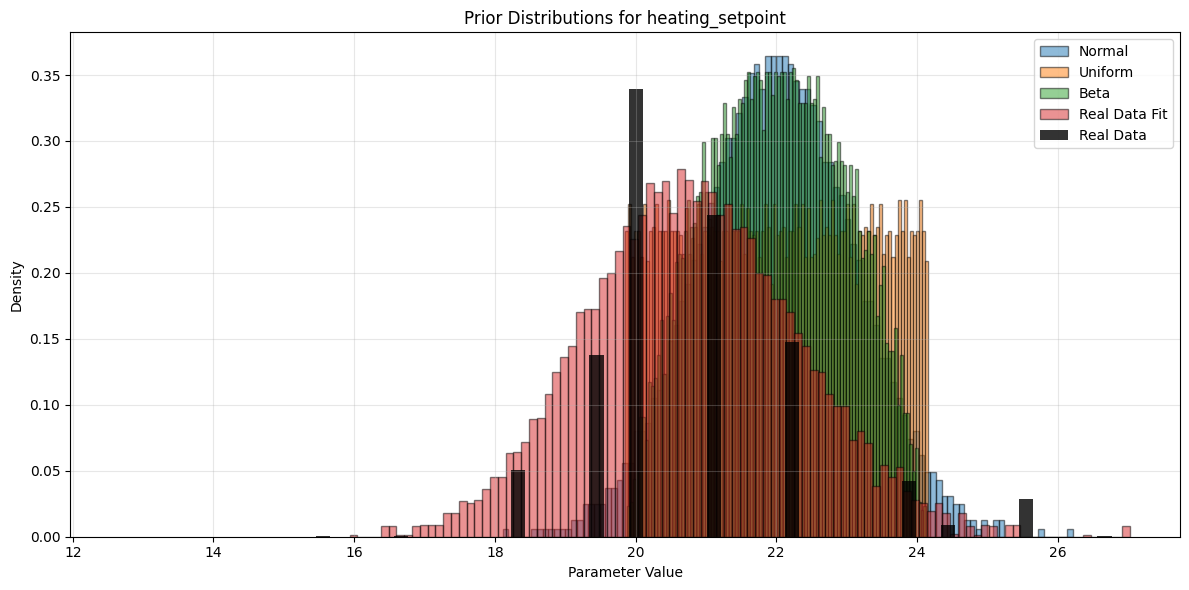

In [19]:
heating_prior = extract_heating_probs()
plot_real_overlay("heating_setpoint", heating_prior)

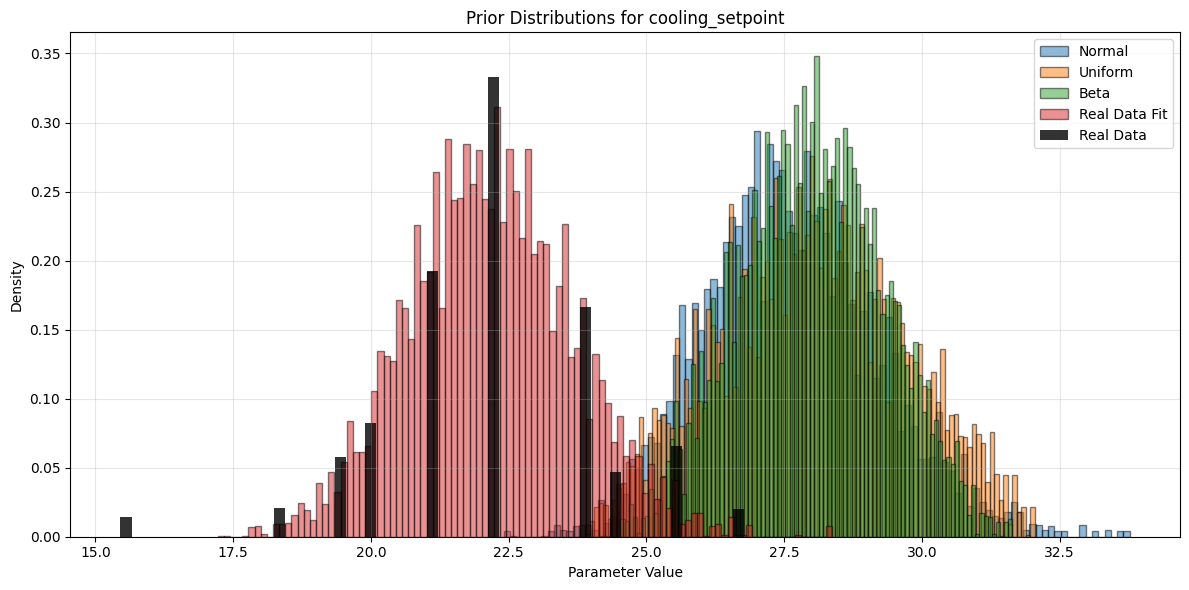

In [20]:
cooling_prior = extract_cooling_probs()
plot_real_overlay("cooling_setpoint", cooling_prior)

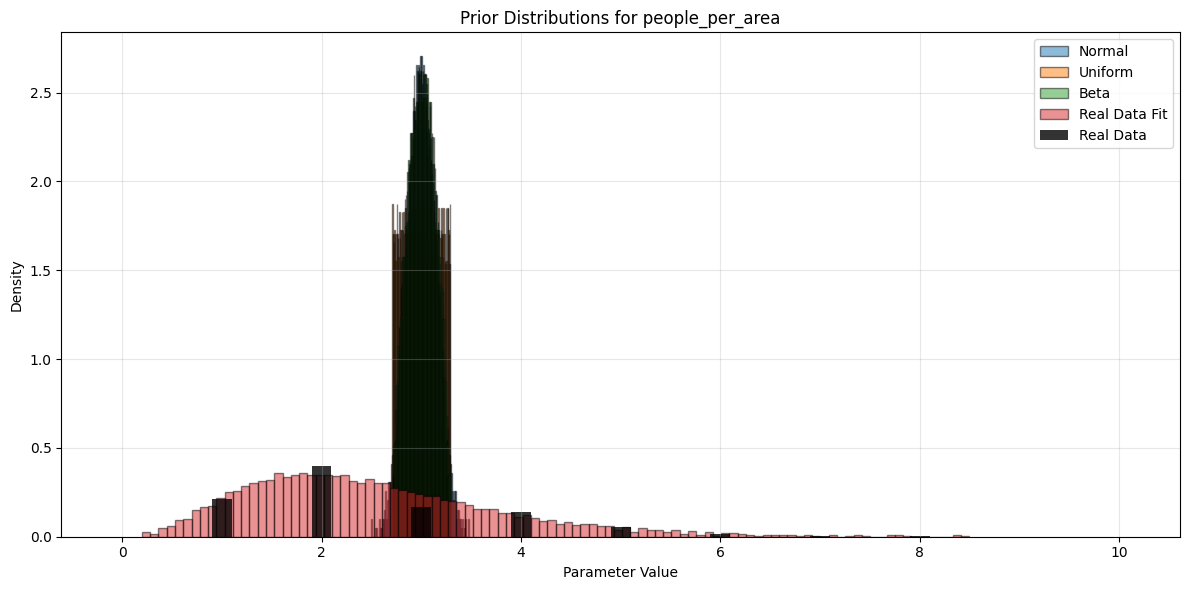

In [22]:
people_prior = extract_people_prior()
plot_real_overlay("people_per_area", people_prior)

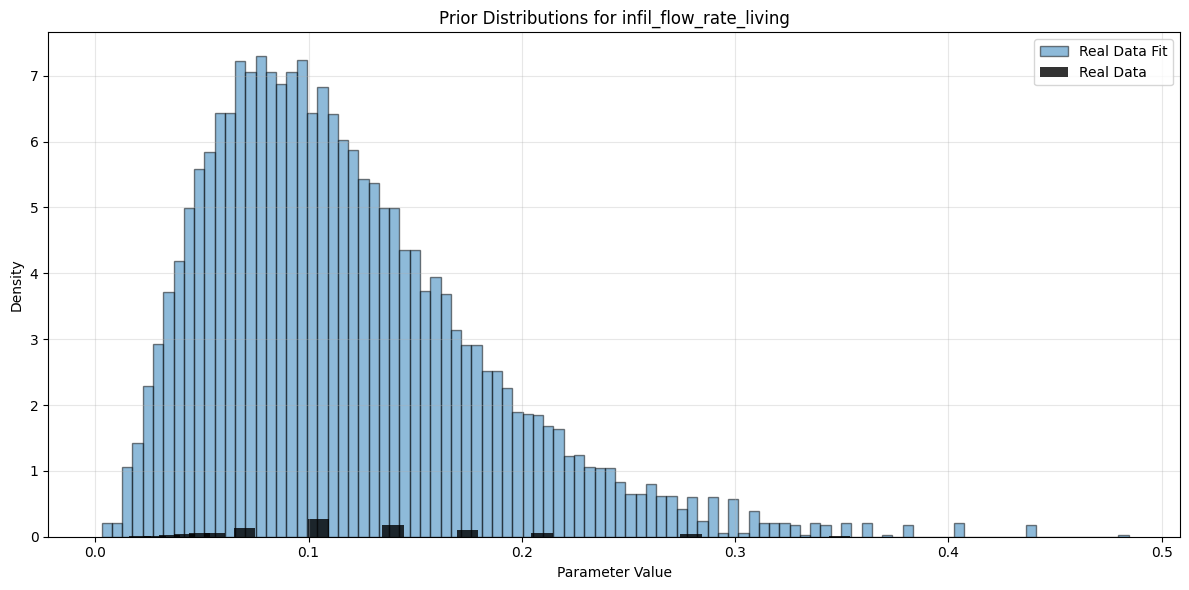

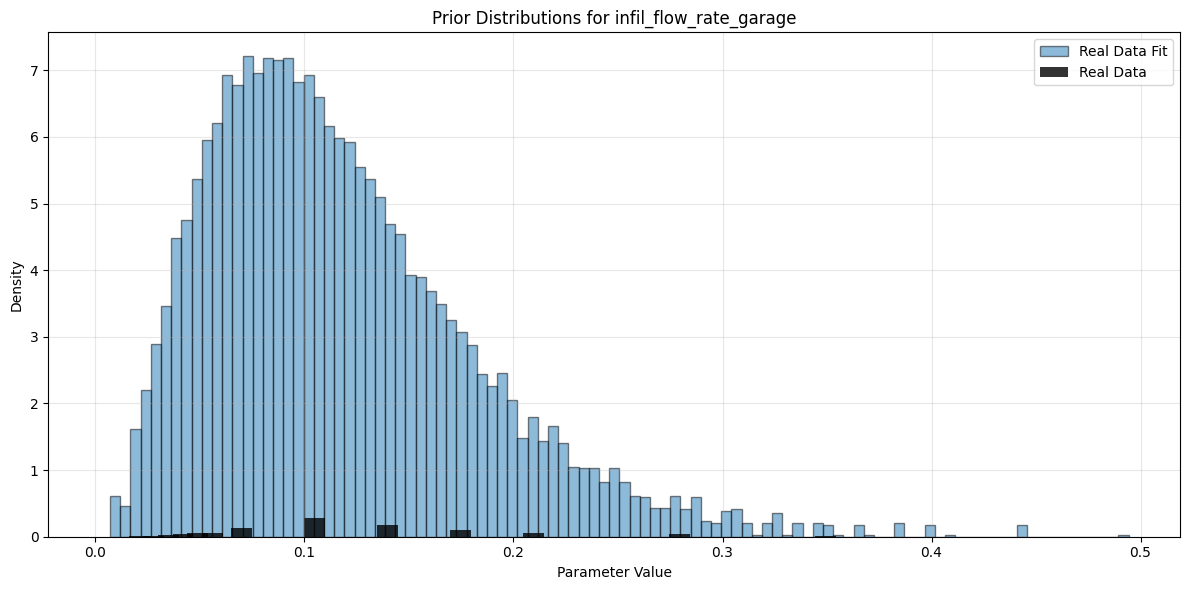

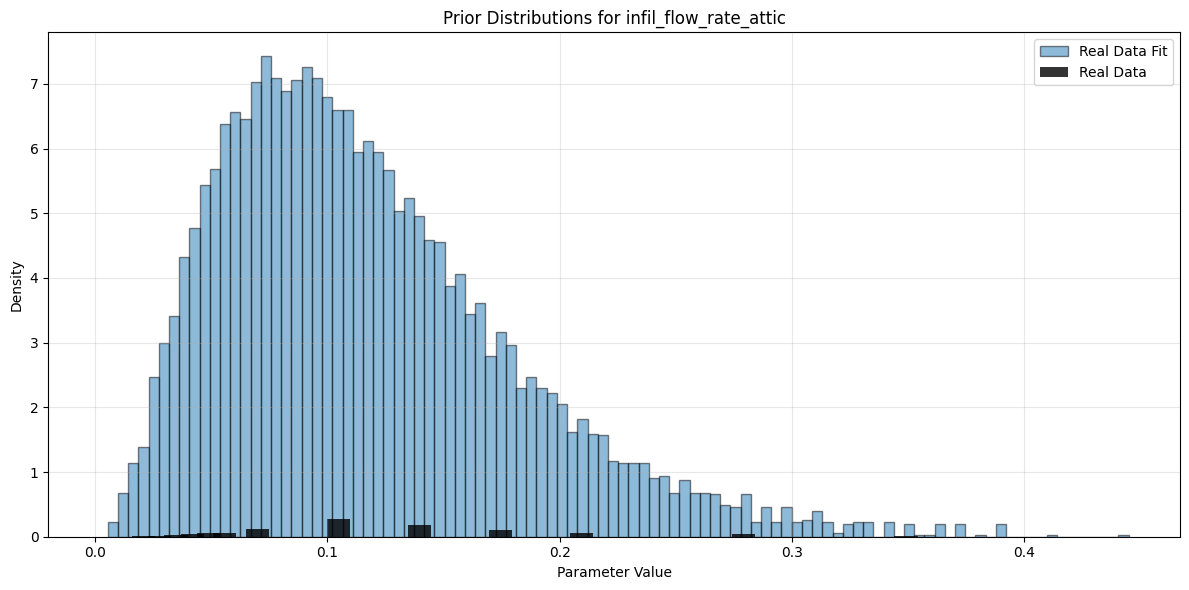

In [31]:
infil_prior = extract_infil_prior()
plot_real_overlay("infil_flow_rate_living", infil_prior)
plot_real_overlay("infil_flow_rate_garage", infil_prior)
plot_real_overlay("infil_flow_rate_attic", infil_prior)
